In [ ]:
# command for starting the kernel:
# python -m pip install ipykernel -> Run in TERMINAL
# python -m ipykernel install --user --name E-Commerce-Sales-and-Customer-Analysis --display-name "E-Commerce-Sales-and-Customer-Analysis (.venv)"
# At the top right corner -> Kernel selector -> Python Environements.... -> select the last one marked with \* .venv\\Scripts\\python.exe
# Verify that the notebook is really using the .venv:
# import sys
# print(sys.executable)

In [2]:
import sys

In [3]:
print(sys.executable)

c:\PYTHON_PRACTICE\E-Commerce-Sales-and-Customer-Analysis\.venv\Scripts\python.exe


In [ ]:
# You're good to go!

In [ ]:
# In terminal:
# pip install pandas
# pip install matplotlib
# pip install seaborn
# pip install openpyxl -> for reading .xlsx files pandas needs this package

In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
# reading the dataset into df using pandas pd
df = pd.read_excel("Online Retail.xlsx")

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [10]:
df.shape

(541909, 8)

In [11]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cu

In [12]:
# Checking the dataset for null/missing values:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(5268)

In [14]:
# Converting the InvoiceDate column to numerical datatype using the to_datetime():
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])


In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# STEP 1:
# creating a new column named Revenue -> to know -> Q How much revenue did each transaction generate?
df["Revenue"] = df["Quantity"] * df["UnitPrice"] # Revenue = Quantity * price per unit

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
# STEP 2:
# Calculating the top 10 revenue by country:
revenue_by_country = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False) # Arranging the values in descending order
    .head(10)
) 
display(revenue_by_country)


Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

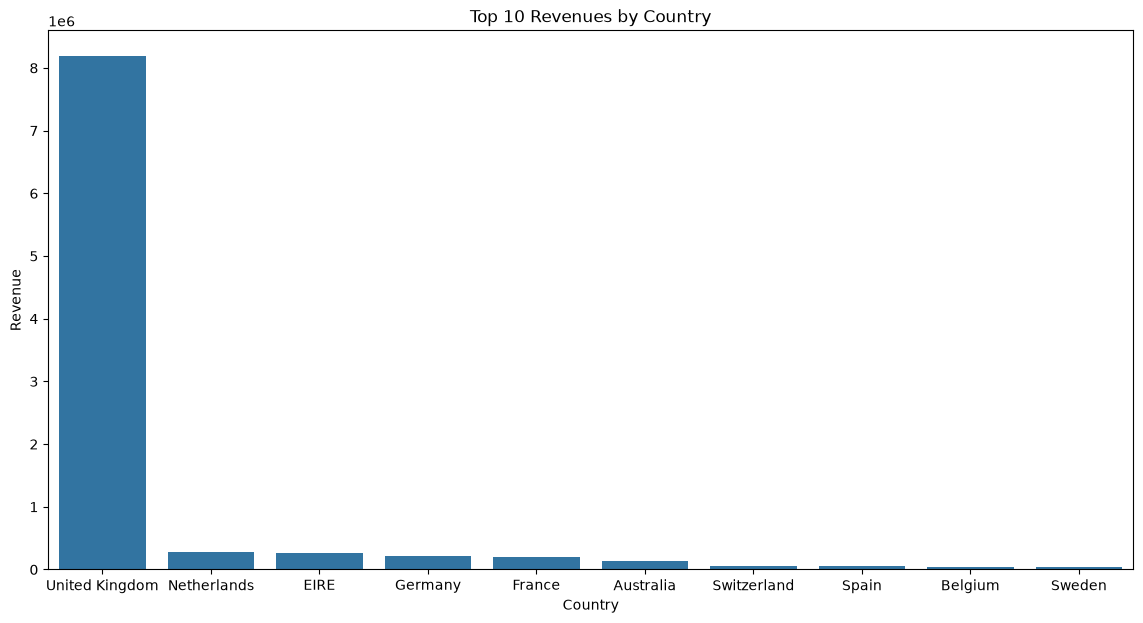

In [44]:
 # STEP 3: 
 # Plotting the top 10 Revenues by country -> using a barplot
plt.figure(figsize=(14,7))
sns.barplot(
    x = revenue_by_country.index,
    y = revenue_by_country.values
)
plt.title("Top 10 Revenues by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.show()


In [46]:
# STEP 4: Q) Which are the top 10 products?
# Identifying the top 10 products -> the 10 products with the highest total Revenue
# creating groups of rows that have the same description, then for each group taking the revenues for those descriptions -> summing up the revenues of all the descriptions in each group
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)  # Arranging the values in descending order so that the largest values are at the top
    .head(10) # Displaying the top 10 values
)
display(top_products)

Description
DOTCOM POSTAGE                        206245.48
REGENCY CAKESTAND 3 TIER              164762.19
WHITE HANGING HEART T-LIGHT HOLDER     99668.47
PARTY BUNTING                          98302.98
JUMBO BAG RED RETROSPOT                92356.03
RABBIT NIGHT LIGHT                     66756.59
POSTAGE                                66230.64
PAPER CHAIN KIT 50'S CHRISTMAS         63791.94
ASSORTED COLOUR BIRD ORNAMENT          58959.73
CHILLI LIGHTS                          53768.06
Name: Revenue, dtype: float64

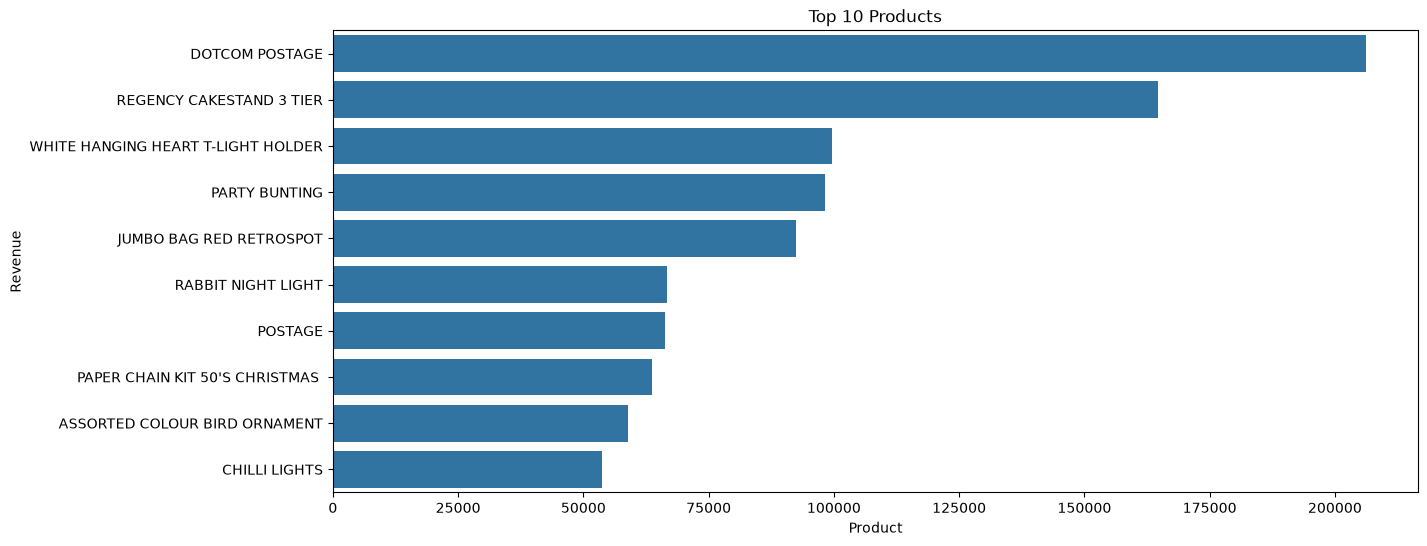

In [48]:
# STEP 5: Plotting the top 10 products using barplot:
plt.figure(figsize=(14,6))
sns.barplot(
    x = top_products.values,
    y = top_products.index
)
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [ ]:
# STEP 6:
# Q to find out how much revenue the business generated in each month over time? 

# Creating a new month column
# Extracting only the month from the InvoiveDate column values
df["Month"] = df["InvoiceDate"].dt.to_period("M")
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,month,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010-12


In [61]:
# STEP 7: Calculating revenue by month:

# Grouping the rows having the same months and then taking only the Revenues column values for each of the groups:
revenue_by_month = (
    df.groupby("Month")["Revenue"]
    .sum()   
)
revenue_by_month.head(13)


Month
2010-12     748957.020
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433668.010
Freq: M, Name: Revenue, dtype: float64

In [ ]:
# The revenues of all rows belonging to month 12  were added up together. Same happened for the other months. -> This shows the revenues generated by the business over time in each month

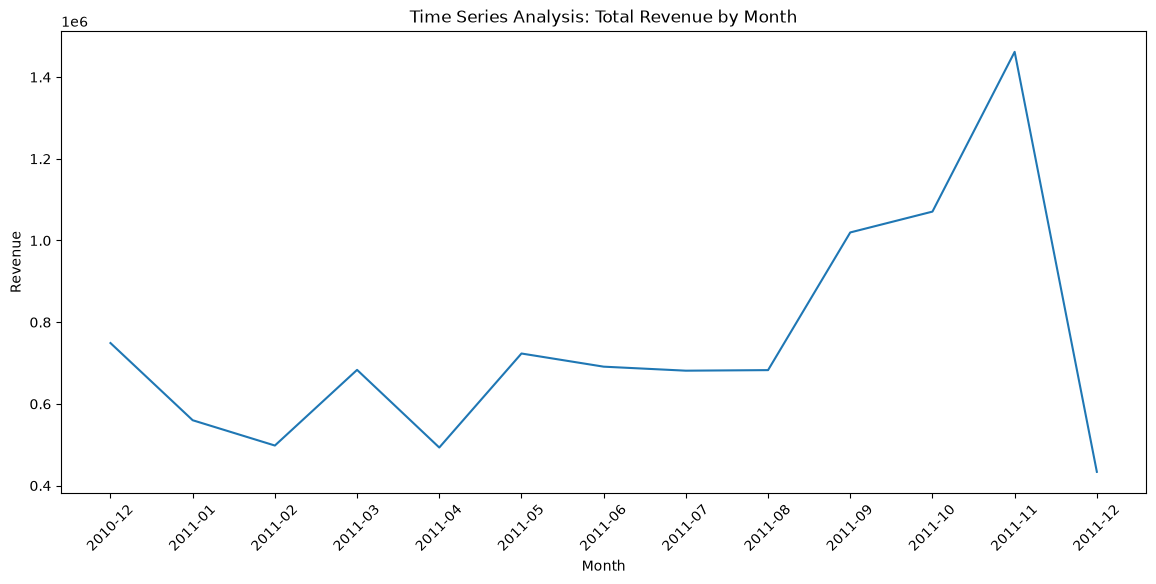

In [62]:
# Now we plot these Revenues generated overtime using Line plot as it is a Time series representation:
plt.figure(figsize=(14, 6))
plt.plot(
    revenue_by_month.index.astype(str),
    revenue_by_month.values
)
plt.title("Time Series Analysis: Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.show()

In [ ]:
# The lineplot shows that the revenue increased every month until the december of 2011
# The revenue peaked in November, 2011 at around 14 lakhs or 1.4 million -> followed by a significant drop in December, 2011 to 4 lakhs or 0.4 million

<Axes: xlabel='Quantity', ylabel='Revenue'>

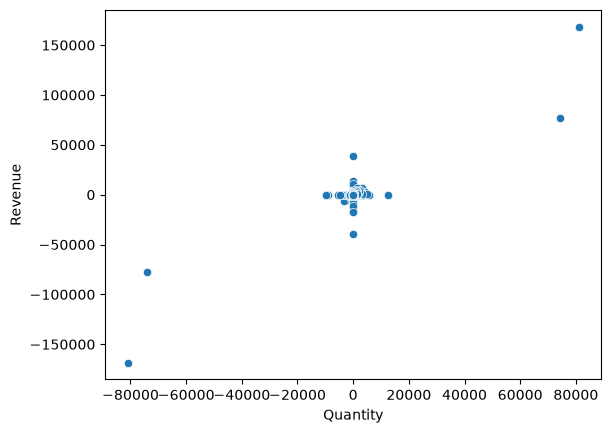

In [64]:
# STEP 8: 
# Creating a scatterplot to compare Quantity VS Revenue
sns.scatterplot(
    x="Quantity",
    y="Revenue",
    data=df
)

In [ ]:
# The scatterplot shows the relationship between Quantity and Revenue:
# Each dot = one row in the DataFrame.
# There is a POSITIVE REALTIONSHIP -> as points move from the bottom left towards the top right -> which indicates that transactions having higher quantities produce higher revenue -> the highest quantity is at around 80000 with revenue of around 170000
# Most of the dots are concentrated around Quantity = 0 and Revenue = 0 -> meaning most of the transactions hev very little quantity and very little revenue compared to a few transactions which have the highest quantities with the highest revenue -> Quantity = 80000 and revenue = 170000
# There are a few extreme positive and negative values that appear as outliers.
# The negative values are likely related to returns or cancelled transactions in the dataset.